# Demo

### Arguments for `compute_dark_diversity`

- `y`  
  Species presence-absence matrix with shape `(n_sites, n_species)`.

- `x`  
  Environmental predictor matrix with shape `(n_sites, n_env)`.

- `model_name`  
  Specifies the ecological response model.  

  Default: `"linear"`

  Options:
  - `"linear"` : linear environmental response model
  - `"gaussian_response_model"` : Gaussian niche response model
  - `"bnn"`: Bayesian neural network

- `num_factors`  
  Number of latent factors used to model residual species covariance.  

  Default: `1`

- `method`  
  Inference method used to fit the model.  

  Default: `"svi"`

  Options:
  - `"svi"` : Stochastic Variational Inference.  
    Optional arguments include:
    - `num_iterations=2500`
    - `lr=0.01`
    - `num_samples=1000`

  - `"mcmc"` : Hamiltonian Monte Carlo using NUTS.  
    Optional arguments include:
    - `num_samples=1000`
    - `warmup_steps=500`

- `cuda`  
  If `True`, computations are performed on GPU when CUDA is available.  
  Only available for SVI.

  Default: `False`

- `include_latent`  
  If `True`, latent factors are included when computing probabilities.

  If `False`, probabilities are computed using environmental effects only.

  Default: `True`

- `return_means`  
  If `True`, returns posterior mean probabilities.

  Otherwise returns full posterior probability samples.

  Default: `True`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Main function
from src.darkdiv import compute_dark_diversity

# Extra functions (plots/evaluation)
from extras.plots import plot_spatial_predictions
from extras.plots import plot_environmental_response
from extras.plots import plot_spatial_uncertainty
from extras.evaluation import compute_overall_error_metrics
from extras.evaluation import compute_species_error_metrics
from extras.evaluation import plot_metric_boxplots


## Prepare input data - pandas dataframes

In [2]:
# Import survey data
y = pd.read_csv("data/survey.csv", index_col=0)
coords = y[["x", "y"]]
y = y.drop(columns=["x", "y", "ID"])
# Rows: sites, Columns: species, Values: presence/absence (1/0)


# Import environmental data
x = pd.read_csv("data/env.csv", index_col=0)
x = x.drop(columns=["landuse", "ID"])
# Rows: sites, Columns: environmental variables, Values: measurements

## 1) Linear model - SVI vs MCMC

In [3]:
p_linear_svi = compute_dark_diversity(y, x, model_name="linear", method = "svi", include_latent = False)

presence_absence
Using device: cpu
Iteration 0 - Loss: 18227.91
Iteration 500 - Loss: 6401.25
Iteration 1000 - Loss: 6322.73
Iteration 1500 - Loss: 6317.48
Iteration 2000 - Loss: 6289.79
SVI converged successfully.


In [4]:
p_linear_mcmc = compute_dark_diversity(y, x, model_name="linear", method = "mcmc", include_latent = False)

presence_absence


Sample: 100%|██████████| 1500/1500 [00:56, 26.75it/s, step size=1.46e-01, acc. prob=0.893]


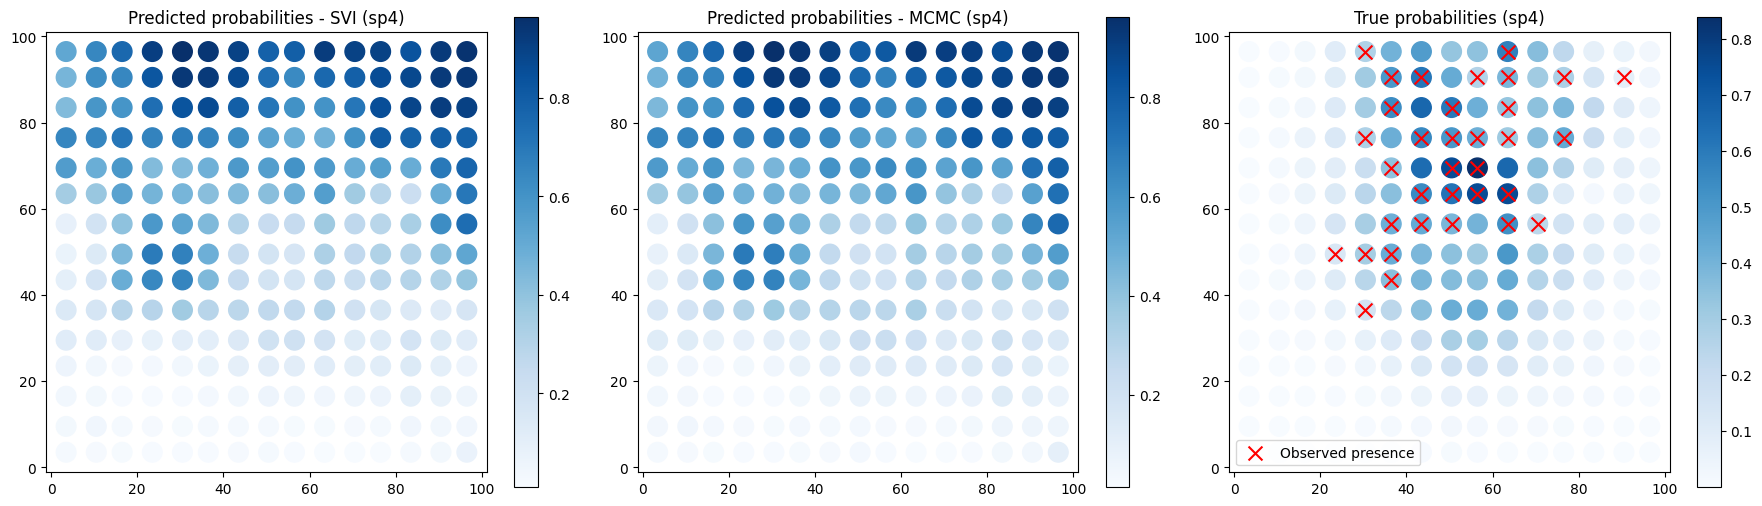

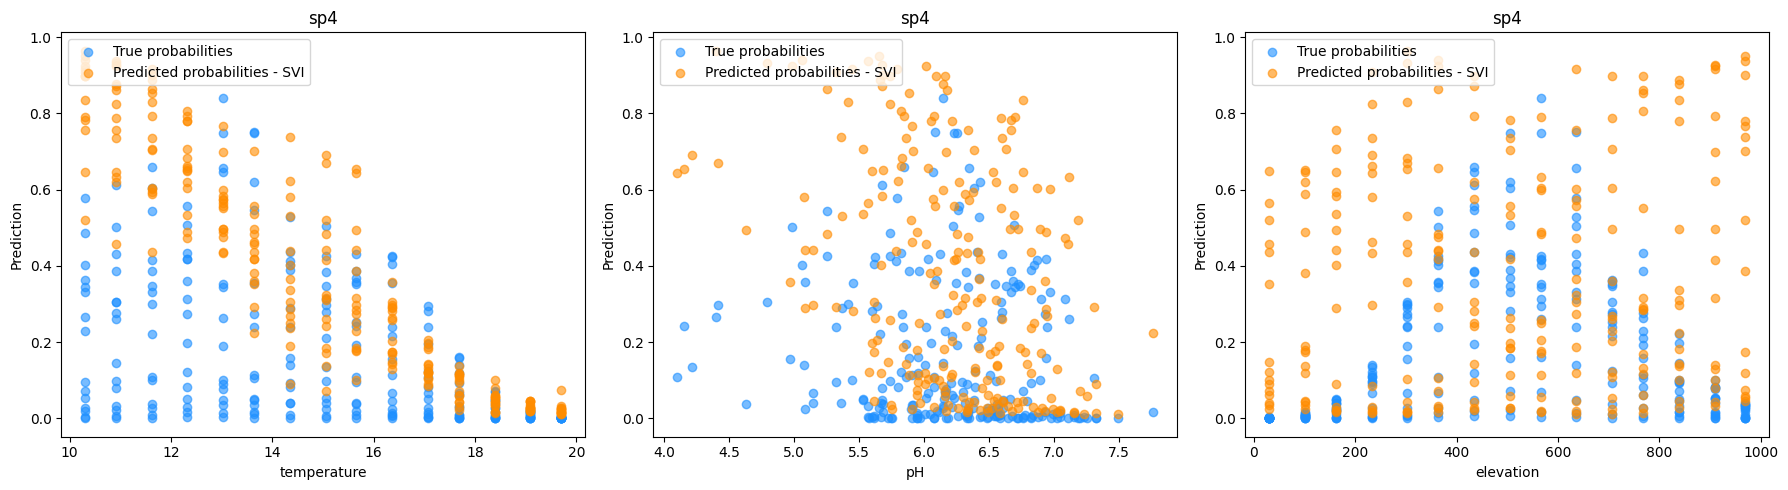

In [5]:
# load the true values
true_values = pd.read_csv("data/truth.csv", index_col=0) # Rows: sites, Columns: species, Values: true probabilities

# Select a species to plot
species_idx = 3
plot_spatial_predictions(coords, [p_linear_svi, p_linear_mcmc, true_values], species_idx, 
                         labels=["Predicted probabilities - SVI", 
                                 "Predicted probabilities - MCMC", 
                                 "True probabilities"],
                                 y = y, presence_ax = [2]) # Plot survey data on top on axis 2

plot_environmental_response(x, [true_values, p_linear_svi], species_idx=species_idx,
                            labels=["True probabilities", 
                                    "Predicted probabilities - SVI"],
                            colors = ["dodgerblue", "darkorange"]
                                    )

## 2) Gaussian response model

We model species occurrence using a Bernoulli distribution with a logit link:

$$
Y_{ij} \sim \text{Bernoulli}(p_{ij})
$$

where

$$
p_{ij} = \text{logit}^{-1}(\eta_{ij})
$$

and the linear predictor is given by

$$
\eta_{ij}
=
\alpha_j
-
\sum_{k=1}^{K}
\gamma_{kj}
\left(
X_{ik} - \mu_{kj}
\right)^2
+
\mathbf{W}_i^\top \mathbf{Z}_j
$$

where:

- $i = 1, \dots, n_{\text{sites}}$
- $j = 1, \dots, n_{\text{species}}$
- $k = 1, \dots, n_{\text{env}}$


In [6]:
# Include latent variables in the predictions
p_gaus_latent = compute_dark_diversity(y, x, model_name = "gaussian_response_model",
                            method = "svi", include_latent = True)

# Do not include latent variables in the predictions
p_gaus_no_latent = compute_dark_diversity(y, x, model_name = "gaussian_response_model",
                            method = "svi", include_latent = False)

presence_absence
Using device: cpu
Iteration 0 - Loss: 11963.72
Iteration 500 - Loss: 5645.17
Iteration 1000 - Loss: 5644.25
Iteration 1500 - Loss: 5636.54
Iteration 2000 - Loss: 5644.48
SVI converged successfully.
presence_absence
Using device: cpu
Iteration 0 - Loss: 11476.31
Iteration 500 - Loss: 5863.66
Iteration 1000 - Loss: 5663.65
Iteration 1500 - Loss: 5640.96
Iteration 2000 - Loss: 5633.15
SVI converged successfully.


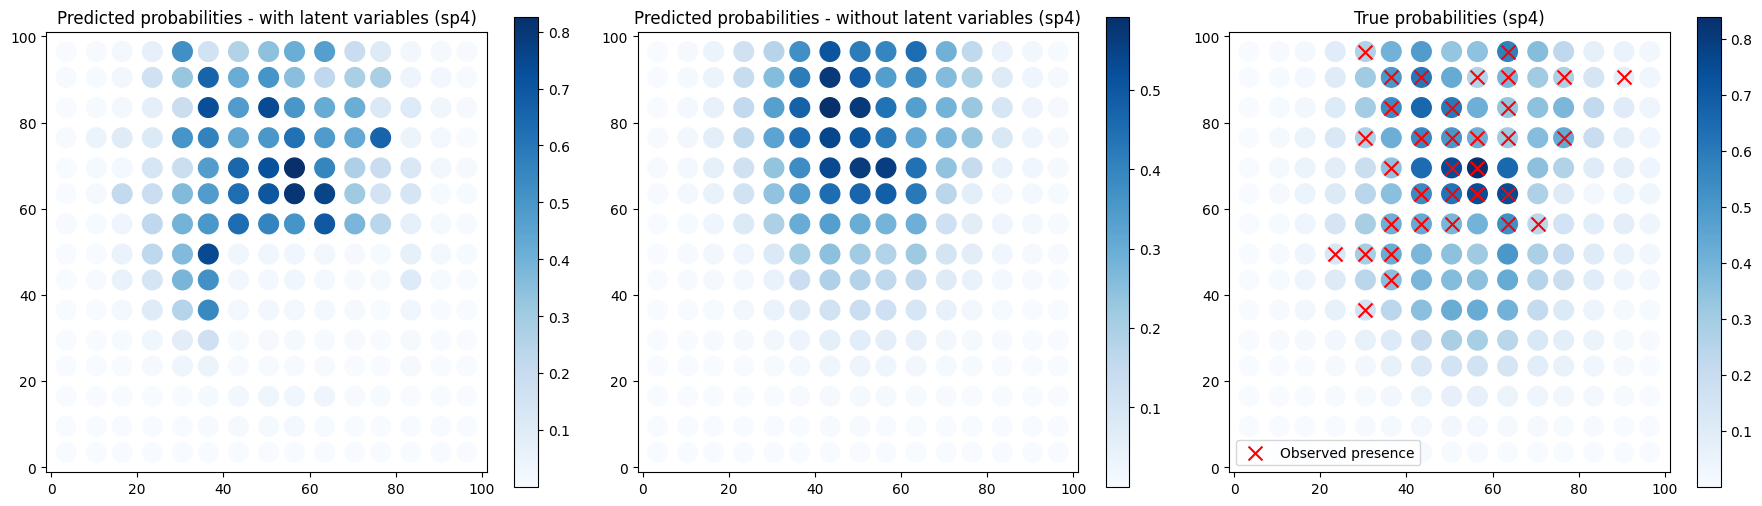

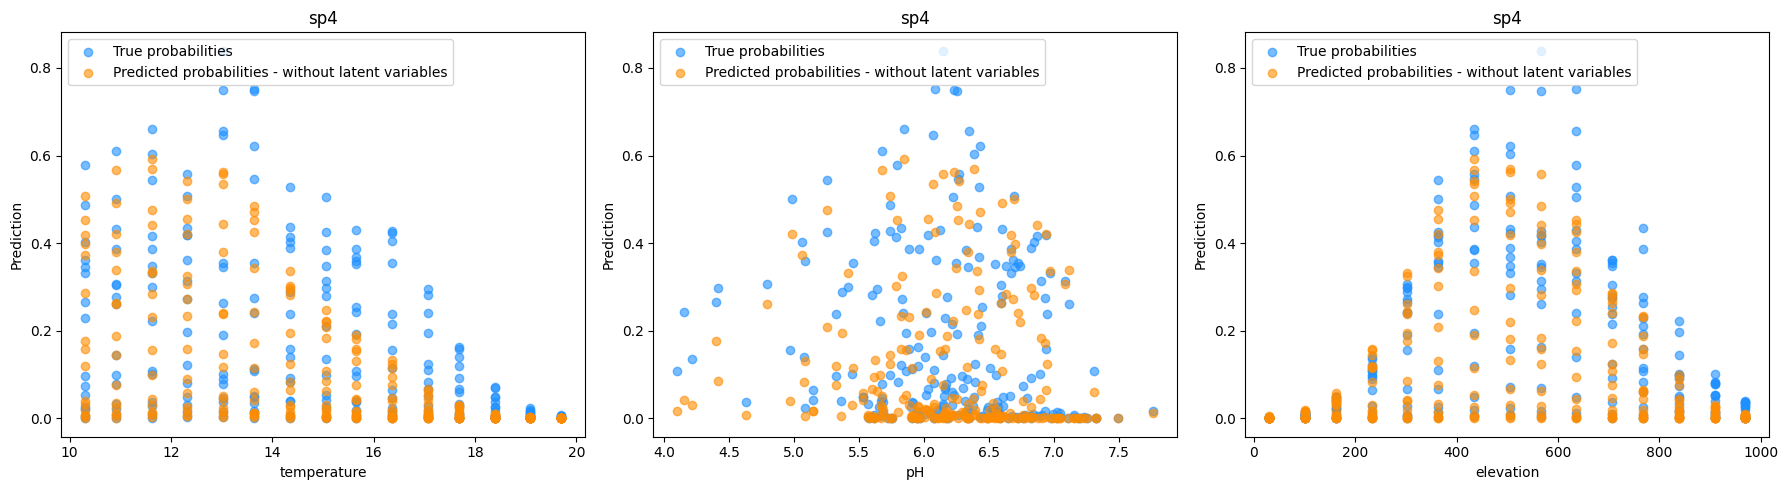

In [7]:
# Select a species to plot
species_idx = 3
plot_spatial_predictions(coords, [p_gaus_latent, p_gaus_no_latent, true_values], species_idx, 
                         labels=["Predicted probabilities - with latent variables", 
                                 "Predicted probabilities - without latent variables", 
                                 "True probabilities"],
                                 y = y, presence_ax = [2]) # Plot survey data on top on axis 2

plot_environmental_response(x, [true_values, p_gaus_no_latent], species_idx=species_idx,
                            labels=["True probabilities", 
                                    "Predicted probabilities - without latent variables"],
                            colors = ["dodgerblue", "darkorange"]
                                    )


## 3) Performance - Linear vs Gaussian model

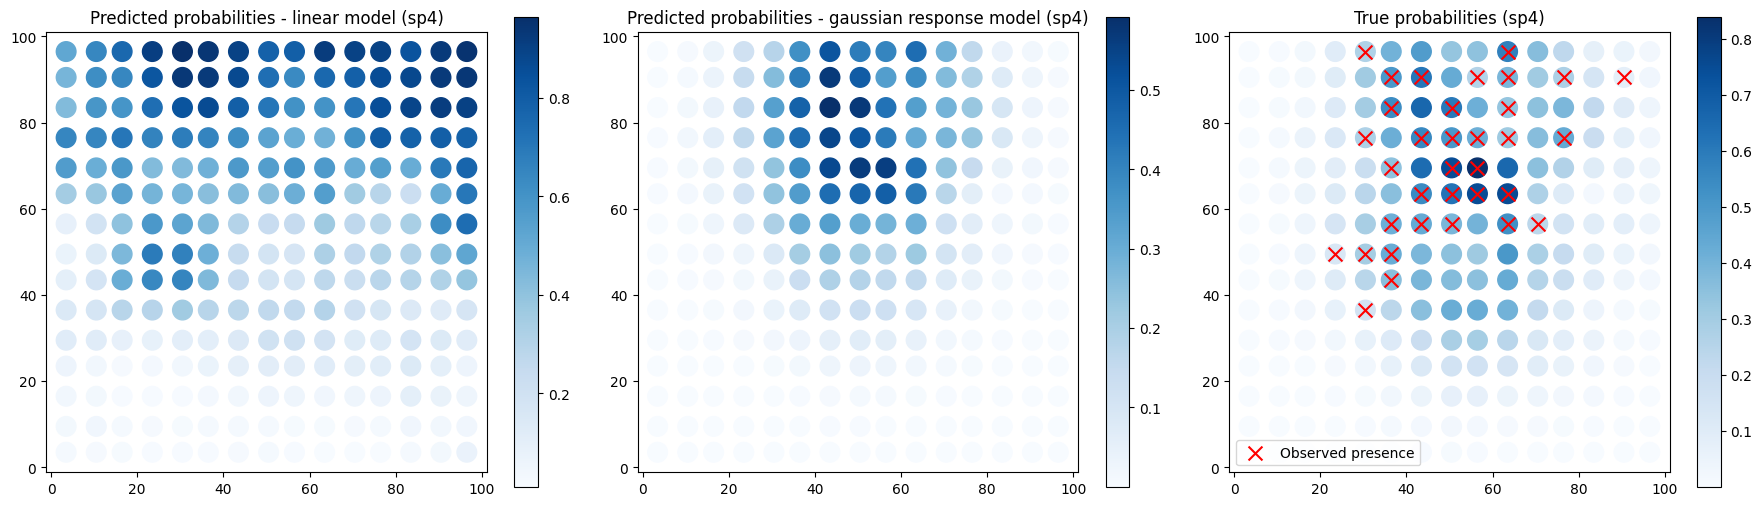

In [8]:
# compare p_linear_svi and p_gaus_no_latent
plot_spatial_predictions(coords, [p_linear_svi, p_gaus_no_latent, true_values], species_idx, 
                         labels=["Predicted probabilities - linear model", 
                                 "Predicted probabilities - gaussian response model",
                                 "True probabilities"],
                                 y = y, presence_ax = [2]) # Plot survey data on top on axis 2

In [9]:
# Overall metrics
metrics_linear_svi = compute_overall_error_metrics(p_linear_svi, true_values)
metrics_gaus_no_latent = compute_overall_error_metrics(p_gaus_no_latent, true_values)
metrics_df = pd.DataFrame({"Metric": list(metrics_linear_svi.keys()),
                           "Linear": list(metrics_linear_svi),
                           "Gaussian": list(metrics_gaus_no_latent)})
print(metrics_df)

        Metric    Linear  Gaussian
0          MSE  0.070720  0.015767
1         RMSE  0.265932  0.125568
2          MAE  0.183978  0.062011
3  Correlation  0.513437  0.858596


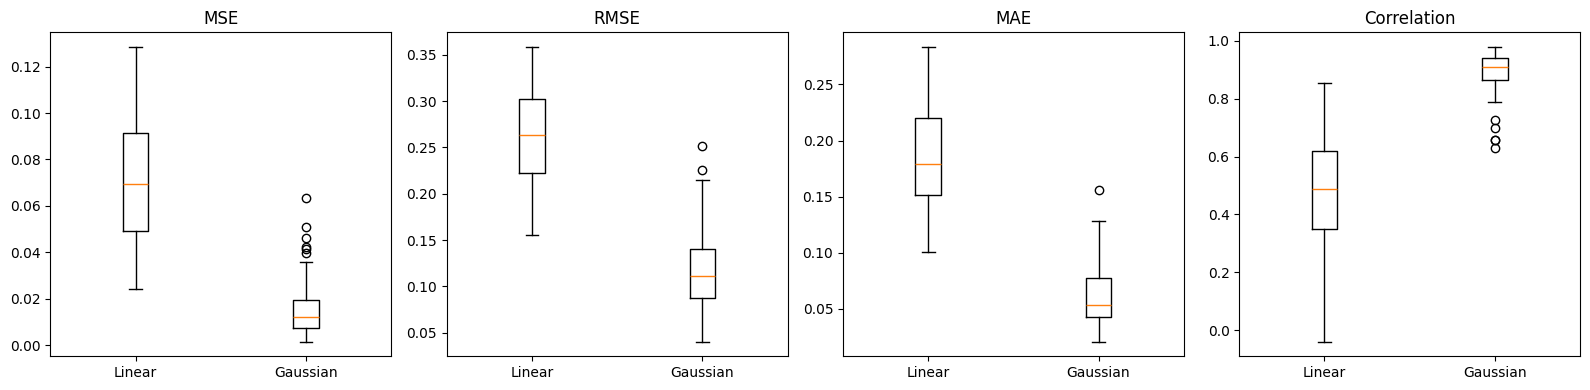

In [10]:
# Species metrics
metrics_species_linear_svi = compute_species_error_metrics(p_linear_svi, true_values)
metrics_species_gaus_no_latent = compute_species_error_metrics(p_gaus_no_latent, true_values)
plot_metric_boxplots(metric_dfs=[metrics_species_linear_svi, metrics_species_gaus_no_latent,], labels=["Linear","Gaussian",],)

## 4) Optimal number of factors?

In [11]:
results = {}

K = 5

for num_factors in range(0,K):
    print(f"Computing dark diversity with {num_factors} latent factors...")
    model_name = f"gaussian_response_model_{num_factors}_factors"

    probabilities = compute_dark_diversity(
        y,
        x,
        model_name="gaussian_response_model",
        num_factors=num_factors,
        method="svi",
        include_latent=False,
    )

    results[model_name] = probabilities
    print('\n')


Computing dark diversity with 0 latent factors...
presence_absence
Using device: cpu
Iteration 0 - Loss: 11750.66
Iteration 500 - Loss: 5843.64
Iteration 1000 - Loss: 5849.33
Iteration 1500 - Loss: 5797.57
Iteration 2000 - Loss: 5817.40
SVI converged successfully.


Computing dark diversity with 1 latent factors...
presence_absence
Using device: cpu
Iteration 0 - Loss: 11833.13
Iteration 500 - Loss: 5640.65
Iteration 1000 - Loss: 5631.58
Iteration 1500 - Loss: 5644.82
Iteration 2000 - Loss: 5585.64
SVI converged successfully.


Computing dark diversity with 2 latent factors...
presence_absence
Using device: cpu
Iteration 0 - Loss: 12465.06
Iteration 500 - Loss: 5786.72
Iteration 1000 - Loss: 5720.59
Iteration 1500 - Loss: 5713.48
Iteration 2000 - Loss: 5712.43
SVI converged successfully.


Computing dark diversity with 3 latent factors...
presence_absence
Using device: cpu
Iteration 0 - Loss: 12787.86
Iteration 500 - Loss: 5853.00
Iteration 1000 - Loss: 5813.87
Iteration 1500 - Loss: 5

In [12]:
metrics = {}

for k, result in results.items():
    # compute over all metrics
    metrics[k] = compute_overall_error_metrics(
        result,
        true_values,
    )

metrics_df = pd.DataFrame(metrics).T
metrics_df.index = [f"{i} latent factors" for i in range(0,K)]
print(metrics_df)

                       MSE      RMSE       MAE  Correlation
0 latent factors  0.013455  0.115995  0.057337     0.872733
1 latent factors  0.015816  0.125760  0.061768     0.858231
2 latent factors  0.016497  0.128442  0.063200     0.857769
3 latent factors  0.016859  0.129842  0.063712     0.857654
4 latent factors  0.017686  0.132988  0.065174     0.852554


## 5) Bayesian Neural Network

In [13]:
# Bayesian neural network
p_bnn = compute_dark_diversity(y, x, model_name = "bnn",
                            method = "svi", include_latent = False, cuda = True, hidden_size=16)

presence_absence
Using device: cuda
Iteration 0 - Loss: 21103.81
Iteration 500 - Loss: 7179.31
Iteration 1000 - Loss: 6721.19
Iteration 1500 - Loss: 6622.91
Iteration 2000 - Loss: 6522.05
SVI converged successfully.


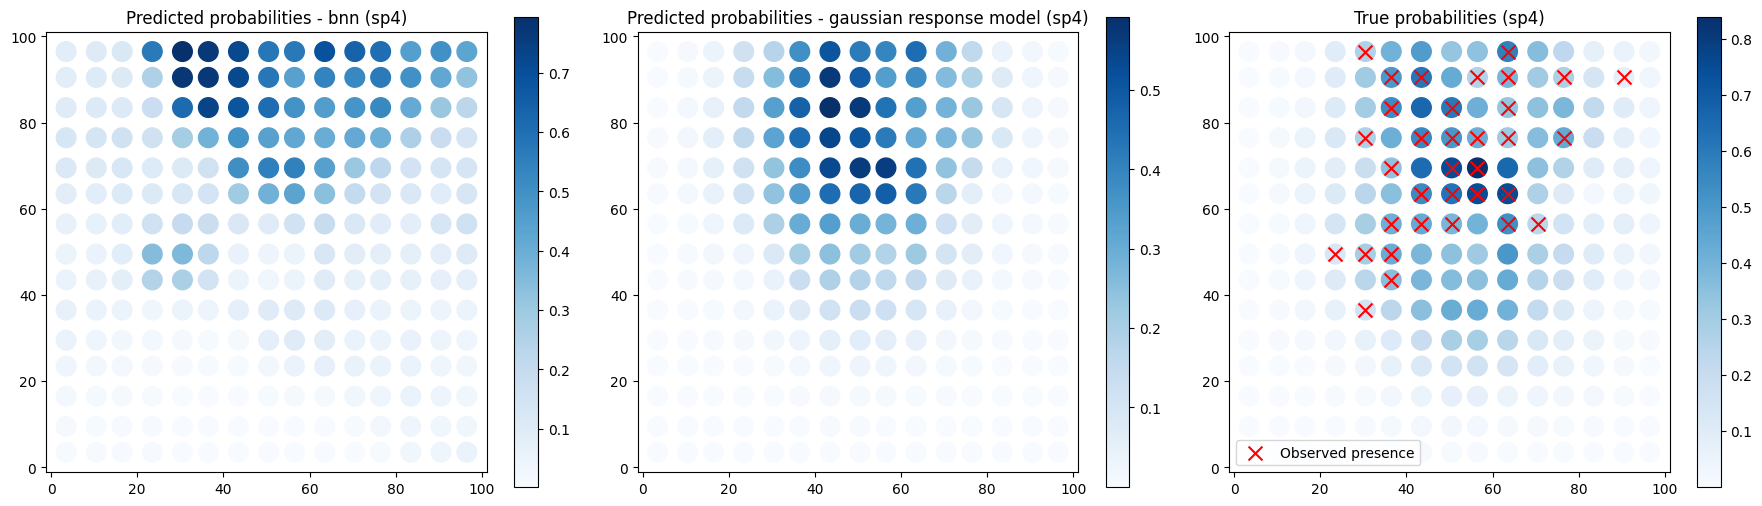

In [14]:
# compare p_linear_svi and p_bnn
plot_spatial_predictions(coords, [p_bnn, p_gaus_no_latent, true_values], species_idx, 
                         labels=["Predicted probabilities - bnn", 
                                 "Predicted probabilities - gaussian response model",
                                 "True probabilities"],
                                 y = y, presence_ax = [2]) # Plot survey data on top on axis 2

In [15]:
# Overall metrics
metrics_linear_svi = compute_overall_error_metrics(p_linear_svi, true_values)
metrics_gaus_no_latent = compute_overall_error_metrics(p_gaus_no_latent, true_values)
metrics_bnn_no_latent = compute_overall_error_metrics(p_bnn, true_values)
metrics_df = pd.DataFrame({"Metric": list(metrics_linear_svi.keys()),
                           "Linear": list(metrics_linear_svi),
                           "Gaussian": list(metrics_gaus_no_latent),
                           "BNN": list(metrics_bnn_no_latent),})
print(metrics_df)

        Metric    Linear  Gaussian       BNN
0          MSE  0.070720  0.015767  0.031858
1         RMSE  0.265932  0.125568  0.178488
2          MAE  0.183978  0.062011  0.109104
3  Correlation  0.513437  0.858596  0.601716


## 6) Distrbution of $p$

In [16]:
p_gaus_samples = compute_dark_diversity(y, x, model_name = "gaussian_response_model",
                            method = "svi", include_latent = False, return_means = False)

presence_absence
Using device: cpu
Iteration 0 - Loss: 11758.18
Iteration 500 - Loss: 5584.76
Iteration 1000 - Loss: 5652.79
Iteration 1500 - Loss: 5635.29
Iteration 2000 - Loss: 5608.82
SVI converged successfully.


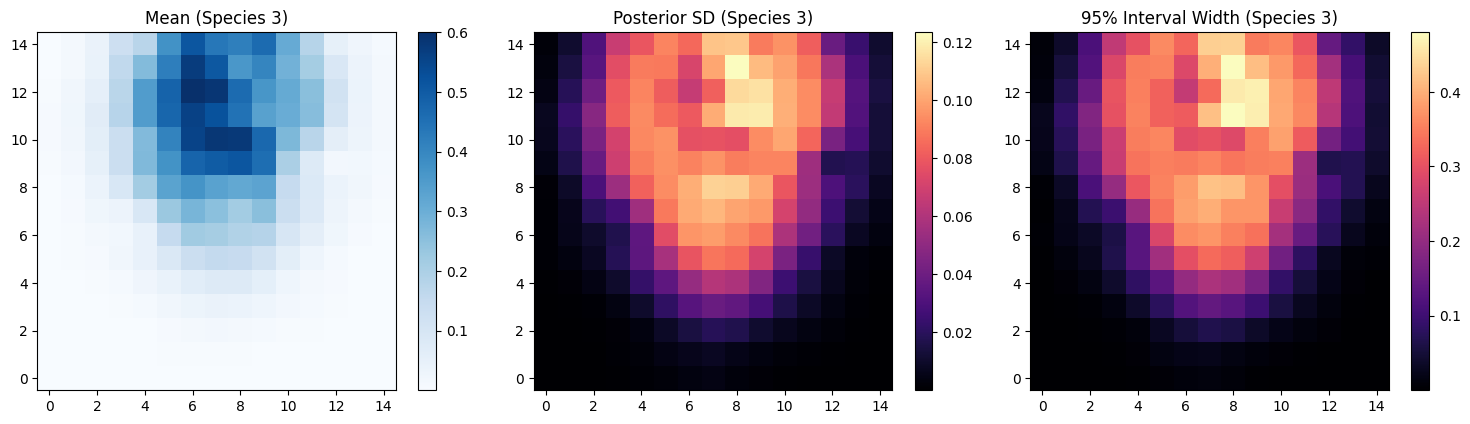

In [17]:
plot_spatial_uncertainty(
    p_gaus_samples,
    species_idx=3,
    grid_shape=(15, 15),
)

## 7) Count data

In [25]:
# Import survey data
y = pd.read_csv("data/survey_counts.csv", index_col=0)
coords = y[["x", "y"]].values
y = y.drop(columns=["x", "y"]) 
# Rows: sites, Columns: species, Values: Number of occurences

count_gaus = compute_dark_diversity(y, x, model_name = "gaussian_response_model", num_factors=1,
                            method = "svi", include_latent = False, return_means = True)

count
Using device: cpu
Iteration 0 - Loss: 97344.23
Iteration 500 - Loss: 21059.23
Iteration 1000 - Loss: 19296.01
Iteration 1500 - Loss: 18068.12
Iteration 2000 - Loss: 17983.89
SVI converged successfully.


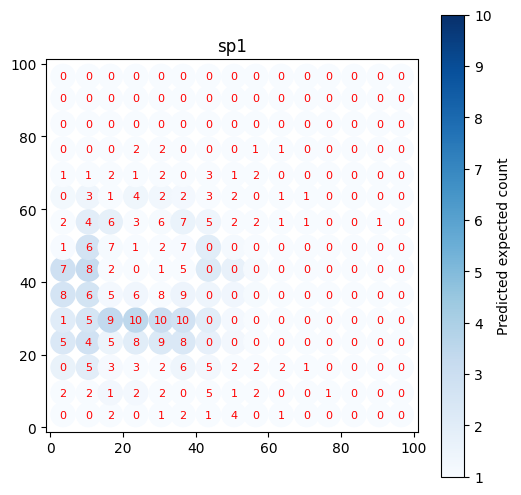

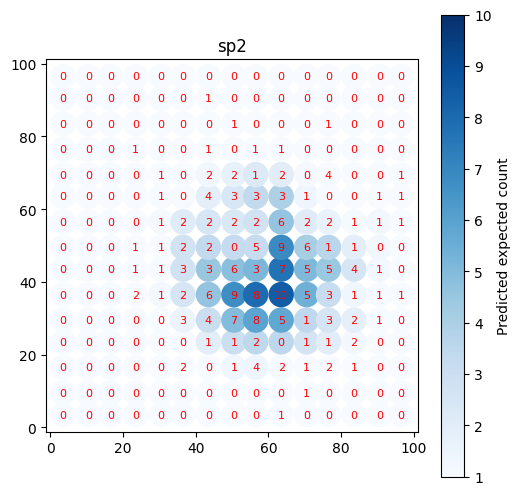

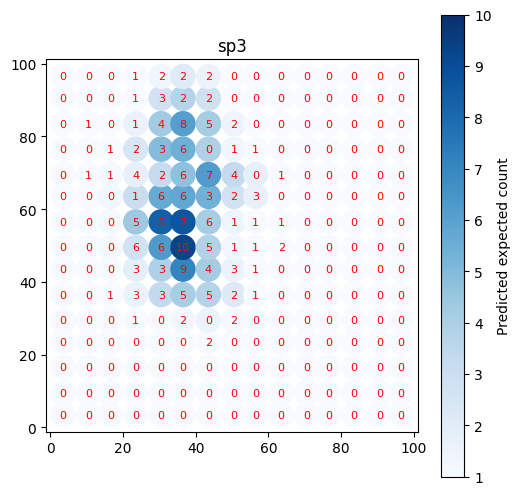

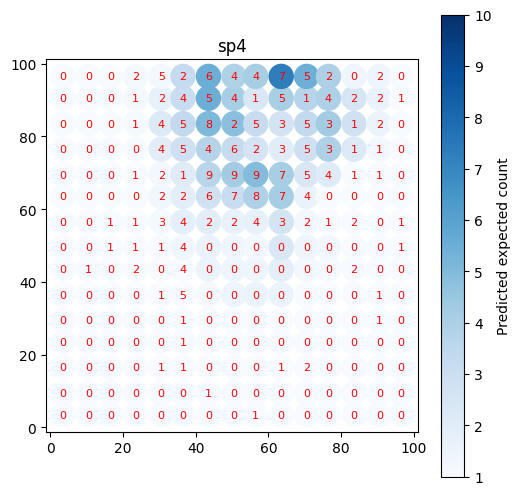

In [26]:
for species_idx in range(0, 4):

    species = y.columns[species_idx]

    plt.figure(figsize=(6, 6))

    sc = plt.scatter(
        coords[:, 0],
        coords[:, 1],
        c=count_gaus.iloc[:, species_idx],
        cmap="Blues",
        s=300,
        vmin=1,
        vmax=10,
    )

    plt.colorbar(
        sc,
        label="Predicted expected count",
    )

    # Add observed counts
    for i in range(len(coords)):

        plt.text(
            coords[i, 0],
            coords[i, 1],
            str(y.iloc[i, species_idx]),
            ha="center",
            va="center",
            fontsize=8,
            color="red",
        )

    plt.gca().set_aspect("equal")

    plt.title(species)

    plt.show()